In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import tensorflow as tf

/Users/macmin/Projects/GitHub/MLE/mlevenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Linear Regression

Given some features, predict a **continuous numerical value**. For example, given the size of a house, predict its price.

We want to fit a linear model to the data — represented by a **line of best fit**:

$$
\hat{y} = mx + b
$$

where $m$ is the slope and $b$ is the intercept.

### Objective

The goal of linear regression is to find the line of best fit — the values of $m$ and $b$ — that **minimize the residuals (errors)** between the line's predictions and the actual data. The smaller the total error, the better the line fits the data.

### Why minimize squared error?

A line of best fit needs some way to score "how good" a candidate line is, so different lines can be compared and the best one picked. The natural approach: for each data point, look at the **residual**/**error** — the vertical gap between the actual value $y_i$ and what the line predicts, $\hat{y}_i$:

$$
\text{residual}_i = y_i - \hat{y}_i
$$

A perfect line would have every residual equal to 0. In practice residuals are a mix of positive (line underestimates) and negative (line overestimates) values, and we want a single number summarizing total error across all points. Just summing the residuals doesn't work — positive and negative errors cancel out, so a line that's wildly wrong in both directions could sum to zero and look "perfect." **Squared error** fixes this by squaring each residual before summing:

$$
\text{squared error}_i = (y_i - \hat{y}_i)^2
$$

Squaring makes every term positive (so errors can't cancel), and it penalizes large errors much more than small ones — a residual of 4 contributes 16, while a residual of 1 only contributes 1. This pushes the fitting process to avoid any single point being wildly off, rather than tolerating one bad miss in exchange for many small ones.

### What is "ordinary least squares"?

**Ordinary least squares (OLS)** is the specific method of choosing $m$ and $b$ that minimize the **sum of squared errors** across all data points:

$$
\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

"Ordinary" distinguishes it from variants (like weighted or generalized least squares) that adjust for things like unequal variance across points — OLS treats every point equally. Minimizing SSE with respect to $m$ and $b$ (via calculus — taking derivatives and setting them to zero) has a closed-form solution, which is where the slope formula below comes from.

The slope that minimizes squared error (ordinary least squares) is:

$$
m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

- $x_i, y_i$ — the individual data points
- $\bar{x}, \bar{y}$ — the mean of the $x$ and $y$ values
- The numerator measures how $x$ and $y$ vary *together*; the denominator measures how much $x$ varies on its own — so $m$ is the ratio of shared variation to $x$'s own variation.

## Linear regression example

In [ ]:
x = np.linspace(500, 3500, 40); y = 50 + 0.15 * x + np.random.default_rng(42).normal(0, 40, 40)
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y, alpha=0.7); plt.plot(x, m * x + b, 'r', label=f'ŷ = {m:.3f}x + {b:.1f}')
plt.xlabel('Square Footage'); plt.ylabel('Price ($1000s)'); plt.title('Square Footage vs Price'); plt.legend(); plt.show()

### Simple vs. Multiple Linear Regression

**Simple linear regression** uses a single feature to predict the target — this is what we've covered so far, fitting a line ($\hat{y} = mx + b$) through one $x$ and one $y$.

$$
\hat{y} = m x + b
$$

**Multiple linear regression** extends this to two or more features — instead of a line, it fits a hyperplane through a higher-dimensional space. Each feature gets its own coefficient:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
$$

- $x_1, x_2, \dots, x_n$ — the individual features (e.g. square footage, number of bedrooms, age of house)
- $w_1, w_2, \dots, w_n$ — the weight/coefficient for each feature, playing the same role $m$ did in simple regression: how much $\hat{y}$ changes per unit change in that feature, holding the others constant
- $b$ — the intercept, same as before

Compactly, this is often written in vector form:

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b
$$

Both are still fit the same way — by minimizing the sum of squared errors (OLS) — the difference is just how many features/coefficients are involved.

## Assumptions of Linear Regression

- **Linearity** — the relationship between features and the target is actually linear. Concretely: as a feature increases, the target changes at a *constant rate* — either consistently up (positive slope, like square footage → price) or consistently down (negative slope, like a car's age → its resale value). What linearity rules out is the rate of change itself *changing* — e.g. the target shooting up fast at first and then leveling off (a curve), which a straight line can't capture no matter how you set $m$ and $b$.
- **Independence** — observations (and their residuals) are independent of one another; no autocorrelation.
- **Homoscedasticity** — residuals have constant variance across all values of $x$ (no "funnel" shape when plotted).
- **Normality of residuals** — residuals are approximately normally distributed, which matters for valid confidence intervals/hypothesis tests.
- **No multicollinearity** (multiple regression only) — features aren't too strongly correlated with each other, or coefficient estimates become unstable.

##### Homoscedasticity: The variance of the residuals is constant across all levels of the independent variable. In this case, the spread of the residuals appears to be relatively consistent across the range of square footage values.

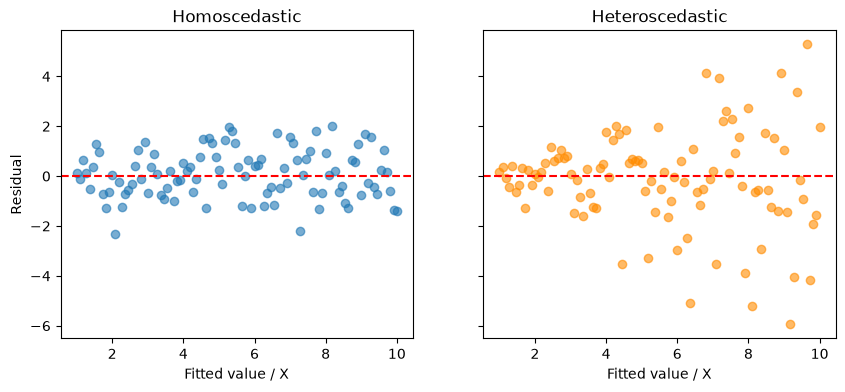

In [4]:
rng = np.random.default_rng(0); x = np.linspace(1, 10, 100)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].scatter(x, rng.normal(0, 1, x.shape), alpha=0.6); axes[0].set_title('Homoscedastic')
axes[1].scatter(x, rng.normal(0, 1, x.shape) * (x / 3), alpha=0.6, color='darkorange'); axes[1].set_title('Heteroscedastic')
for ax in axes: ax.axhline(0, color='r', linestyle='--'); ax.set_xlabel('Fitted value / X')
axes[0].set_ylabel('Residual'); plt.show()

#### Normality of residuals

**In simple terms:** if you plot how far off each prediction was, those errors should look roughly like a bell curve centered at 0 — not lopsided in one direction.

The **Q-Q plots** below are the easiest way to check this. Each dot compares one residual to where it *should* fall if residuals were perfectly normal. The **diagonal line** represents "perfectly normal" — the closer the dots hug that line, the more normal the residuals are.

- **Left pair:** normal residuals → dots hug the diagonal closely.
- **Right pair:** skewed residuals → dots curve away from the diagonal, especially at the ends — a visible sign this assumption is violated.

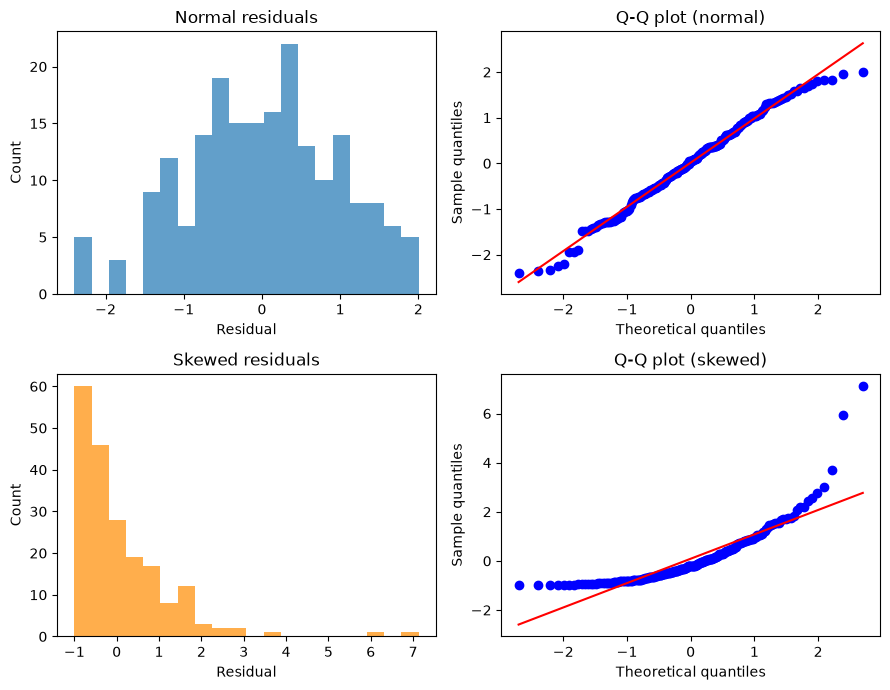

In [7]:
rng = np.random.default_rng(0)
normal_resid = rng.normal(0, 1, 200); skewed_resid = rng.exponential(1, 200) - 1

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].hist(normal_resid, bins=20, alpha=0.7); axes[0, 0].set_title('Normal residuals')
axes[0, 0].set_xlabel('Residual'); axes[0, 0].set_ylabel('Count')
stats.probplot(normal_resid, plot=axes[0, 1]); axes[0, 1].set_title('Q-Q plot (normal)')
axes[0, 1].set_xlabel('Theoretical quantiles'); axes[0, 1].set_ylabel('Sample quantiles')
axes[1, 0].hist(skewed_resid, bins=20, alpha=0.7, color='darkorange'); axes[1, 0].set_title('Skewed residuals')
axes[1, 0].set_xlabel('Residual'); axes[1, 0].set_ylabel('Count')
stats.probplot(skewed_resid, plot=axes[1, 1]); axes[1, 1].set_title('Q-Q plot (skewed)')
axes[1, 1].set_xlabel('Theoretical quantiles'); axes[1, 1].set_ylabel('Sample quantiles')
plt.tight_layout(); plt.show()

#### No multicollinearity

**In simple terms:** in multiple regression, the features themselves shouldn't be strongly correlated with each other. If two features move almost in lockstep (e.g. square footage and number of rooms), the model can't cleanly tell which one is actually driving the target — their coefficients become unstable and hard to interpret, even if the model's overall predictions still look fine.

The **correlation heatmap** below shows this for two feature sets: one where features are largely independent (low correlation, safe for OLS), and one where two features are highly correlated (high multicollinearity, risky for OLS).

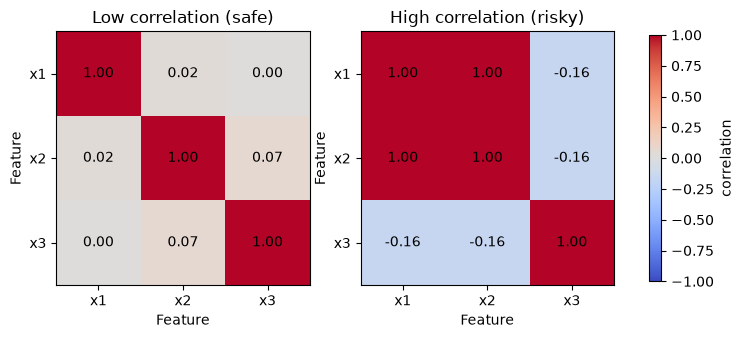

In [ ]:
rng = np.random.default_rng(0)
low_corr = rng.normal(0, 1, (100, 3))
high_corr = np.column_stack([rng.normal(0, 1, 100)] * 2 + [rng.normal(0, 1, 100)])
high_corr[:, 1] += high_corr[:, 0] * 3  # force feature 1 to closely track feature 0
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, data, title in zip(axes, [low_corr, high_corr], ['Low correlation (safe)', 'High correlation (risky)']):
    corr = np.corrcoef(data.T)
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['x1', 'x2', 'x3']); ax.set_yticklabels(['x1', 'x2', 'x3'])
    ax.set_xlabel('Feature'); ax.set_ylabel('Feature')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center')

fig.colorbar(im, ax=axes, shrink=0.8, label='correlation')
plt.show()

## Evaluation of Linear Regression Models

### 1. Mean Absolute Error (MAE)

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**In simple terms:** MAE is the *average size* of the model's errors, in the same units as the target (e.g. dollars, if predicting price). Unlike squared error, it doesn't square the residuals — so a $10 miss counts as $10, not $100. This makes MAE easier to interpret directly, and less sensitive to a few large outliers than squared-error-based metrics (like SSE or MSE).

The diagram below shows the same fitted line as earlier, with dashed vertical lines marking each point's absolute error — MAE is just the average length of those dashed lines.

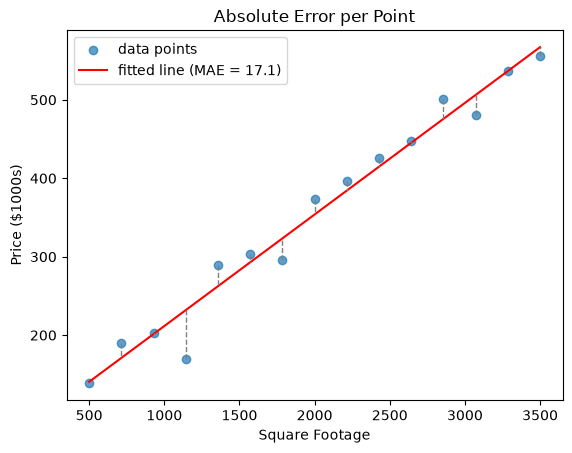

In [10]:
x = np.linspace(500, 3500, 15); y = 50 + 0.15 * x + np.random.default_rng(1).normal(0, 40, 15)
m, b = np.polyfit(x, y, 1); y_pred = m * x + b
mae = np.mean(np.abs(y - y_pred))

plt.scatter(x, y, alpha=0.7, label='data points')
plt.plot(x, y_pred, 'r', label=f'fitted line (MAE = {mae:.1f})')
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], 'gray', linestyle='--', linewidth=1)
plt.xlabel('Square Footage'); plt.ylabel('Price ($1000s)'); plt.title('Absolute Error per Point'); plt.legend(); plt.show()

### 2. Root Mean Squared Error (RMSE)

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**In simple terms:** RMSE first squares each residual (like SSE does), averages those squared errors, then takes the square root to bring the units back to the target's original scale (e.g. dollars again, not dollars²). Because it squares first, RMSE — unlike MAE — penalizes large errors disproportionately: one point that's way off will inflate RMSE much more than it inflates MAE, since that single squared term dominates the average.

**How this relates to MSE:** RMSE is literally just $\sqrt{\text{MSE}}$ — Mean Squared Error is the average of the squared residuals (the same quantity under the square root above), and RMSE is that same value with the square root applied at the end. They rank models identically (whichever has lower MSE also has lower RMSE), so the only real difference is units: MSE is in squared units (dollars², unintuitive), while RMSE is back in the original units (dollars), which is why RMSE is almost always reported instead of MSE when communicating results — MSE mainly shows up as an intermediate step, e.g. inside a loss function during training where the extra square root isn't needed.

**When to use RMSE (or MSE) over MAE:** reach for RMSE/MSE when large errors are genuinely worse than proportionally many small ones — e.g. a few wildly wrong predictions are more costly or dangerous than being consistently a little off. Reach for MAE when you want a robust, easily-interpretable "typical error" that isn't dominated by a handful of outliers, or when outliers in the data are noise you don't want to overweight. In short: MAE tells you the *typical* miss; RMSE/MSE tell you how bad the *worst* misses are.

The diagram below reuses the same data and fitted line as the MAE example, but adds one **outlier** point. Compare how much more RMSE jumps compared to MAE — that gap is exactly what squaring does.

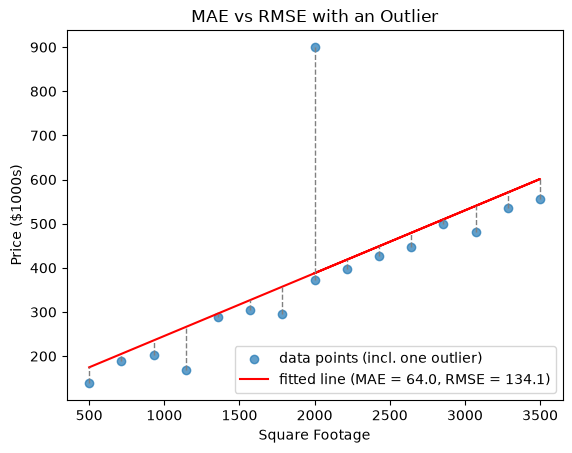

In [11]:
x = np.append(np.linspace(500, 3500, 15), 2000); y = np.append(50 + 0.15 * np.linspace(500, 3500, 15) + np.random.default_rng(1).normal(0, 40, 15), 900)  # last point is an outlier
m, b = np.polyfit(x, y, 1); y_pred = m * x + b
mae = np.mean(np.abs(y - y_pred)); rmse = np.sqrt(np.mean((y - y_pred) ** 2))

plt.scatter(x, y, alpha=0.7, label='data points (incl. one outlier)')
plt.plot(x, y_pred, 'r', label=f'fitted line (MAE = {mae:.1f}, RMSE = {rmse:.1f})')
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], 'gray', linestyle='--', linewidth=1)
plt.xlabel('Square Footage'); plt.ylabel('Price ($1000s)'); plt.title('MAE vs RMSE with an Outlier'); plt.legend(); plt.show()

## Linear Regression Exercise

#### Seoul Bike Sharing Demand Prediction

https://www.kaggle.com/datasets/saurabhshahane/seoul-bike-sharing-demand-prediction

In [2]:
path = kagglehub.dataset_download("saurabhshahane/seoul-bike-sharing-demand-prediction")
print(path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(f"{path}/{csv_file}", encoding='cp1252').drop(["Date", "Holiday", "Seasons"], axis=1)

/Users/macmin/.cache/kagglehub/datasets/saurabhshahane/seoul-bike-sharing-demand-prediction/versions/1


In [3]:
df = df.rename(columns={
    "Rented Bike Count": "bike_count",
    "Hour": "hour",
    "Temperature(°C)": "temp",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "wind",
    "Visibility (10m)": "visibility",
    "Dew point temperature(°C)": "dew_pt_temp",
    "Solar Radiation (MJ/m2)": "radiation",
    "Rainfall(mm)": "rain",
    "Snowfall (cm)": "snow",
    "Functioning Day": "functional",
})

In [4]:
df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12] # filter to Noon
df = df.drop(["hour"], axis=1)

In [45]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


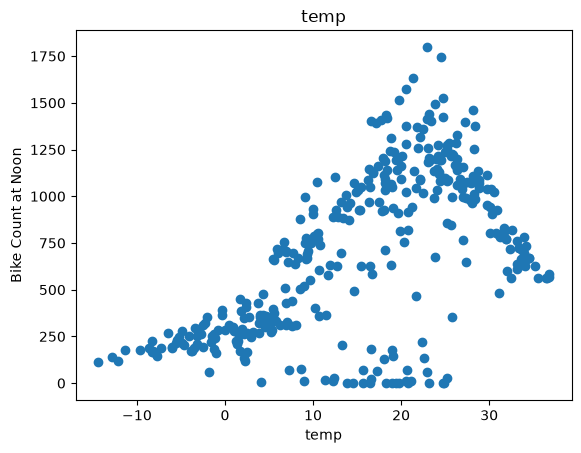

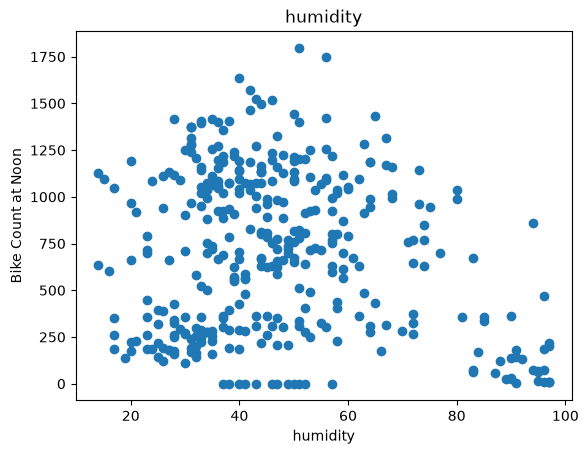

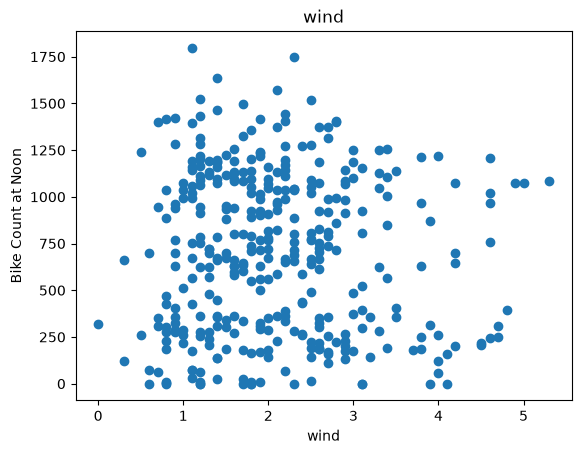

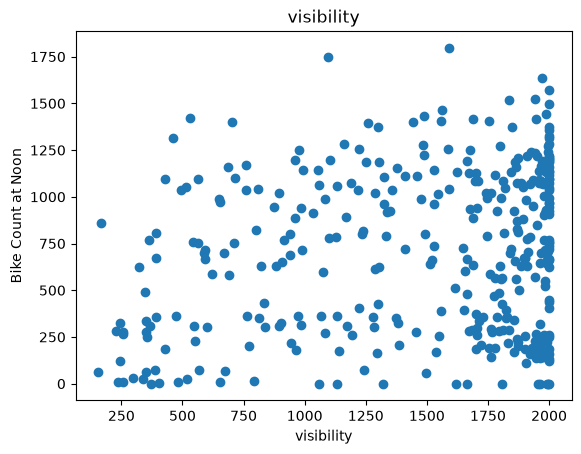

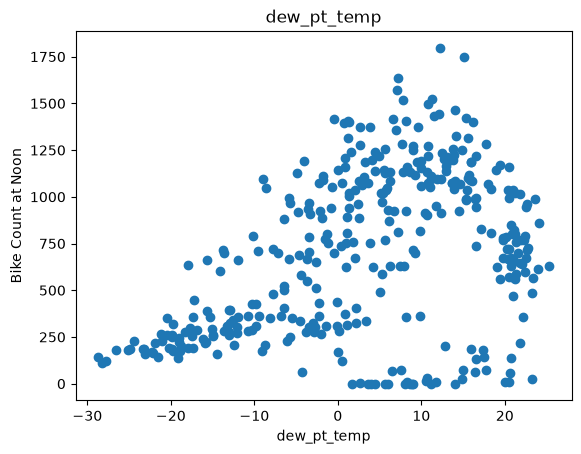

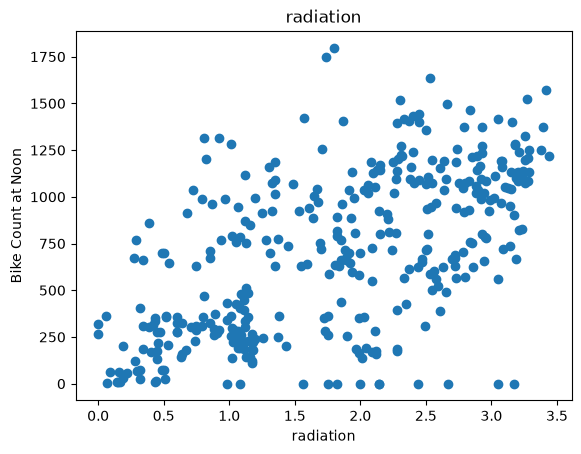

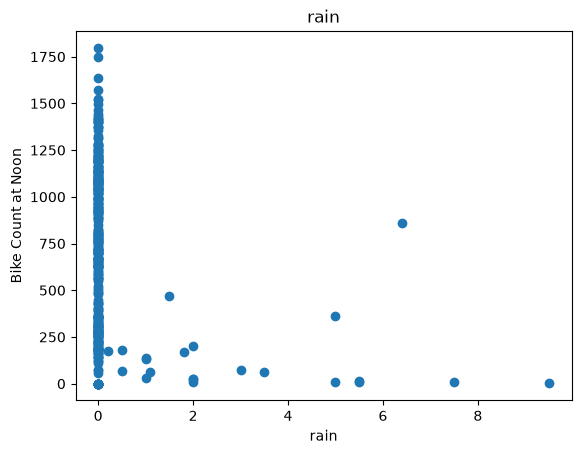

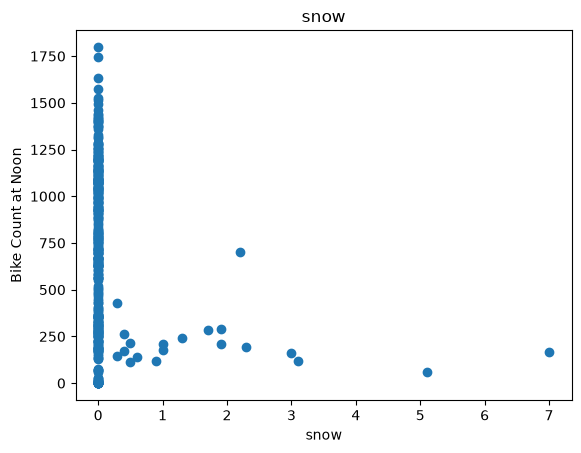

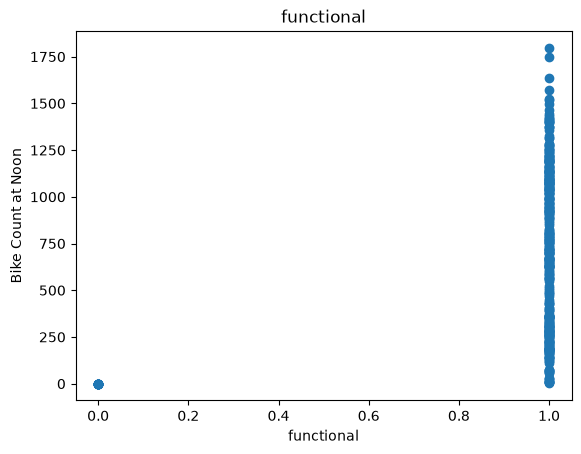

In [46]:
for label in df.columns[1:]:
  plt.scatter(df[label], df["bike_count"])
  plt.title(label)
  plt.ylabel("Bike Count at Noon")
  plt.xlabel(label)
  plt.show()

In [5]:
df = df.drop(["wind", "visibility", "functional"], axis=1)

### Train / validation / test split

`df.sample(frac=1, random_state=42)` shuffles all rows into a reproducible random order. `.iloc` then cuts that shuffled DataFrame into three chunks:

- **`train_df`** (first 60% of rows) — used to fit the model.
- **`val_df`** (next 20%, from the 60% mark to the 80% mark) — held out during training and used to check generalization.
- **`test_df`** (last 20%, from the 80% mark onward) — held out for final evaluation.

Both the temperature-only and multiple-feature regressions reuse these same DataFrames, so their test-set $R^2$ scores are directly comparable.

In [12]:
shuffled = df.sample(frac=1, random_state=42)
train_end, val_end = int(0.6 * len(df)), int(0.8 * len(df))
train_df, val_df, test_df = shuffled.iloc[:train_end], shuffled.iloc[train_end:val_end], shuffled.iloc[val_end:]

In [7]:
def get_xy(dataframe, y_label, x_labels=None):
  if x_labels is None:
    X = dataframe[[c for c in dataframe.columns if c!=y_label]].values
  else:
    if len(x_labels) == 1:
      X = dataframe[x_labels[0]].values.reshape(-1, 1)
    else:
      X = dataframe[x_labels].values

  y = dataframe[y_label].values.reshape(-1, 1)
  data = np.hstack((X, y)) # Stacking horizontally next to each other 

  return data, X, y

The train, validation, and test feature/target arrays are created from the DataFrame splits above:

- `train_df` is used to fit the model.
- `val_df` is used for validation.
- `test_df` is held out for final evaluation.

In [13]:
_, X_train_temp, y_train_temp = get_xy(train_df, "bike_count", x_labels=["temp"])
_, X_val_temp, y_val_temp = get_xy(val_df, "bike_count", x_labels=["temp"])
_, X_test_temp, y_test_temp = get_xy(test_df, "bike_count", x_labels=["temp"])

In [14]:
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[21.75]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[375.95]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[174.73]


In [59]:
print(temp_reg.coef_, temp_reg.intercept_)

[[21.49287698]] [405.61362093]


In [15]:
temp_reg.score(X_test_temp, y_test_temp)

0.1724911525262579

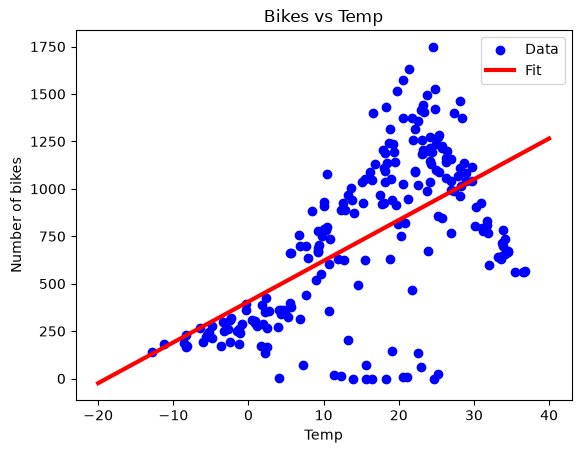

In [73]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

## Multiple Linear Regression

Use all columns except `bike_count` as features to predict the bike count.

In [16]:
# Reuse the same train/validation/test split as the temperature-only model
# so the two R^2 scores are directly comparable.
feature_columns = [column for column in df.columns if column != "bike_count"]

_, X_train_all, y_train_all = get_xy(train_df, "bike_count", x_labels=feature_columns)
_, X_val_all, y_val_all = get_xy(val_df, "bike_count", x_labels=feature_columns)
_, X_test_all, y_test_all = get_xy(test_df, "bike_count", x_labels=feature_columns)

all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)
all_reg.score(X_test_all, y_test_all)

0.46190870435014975

### Interpreting the $R^2$ scores

The temperature-only model has an $R^2$ score of **0.17**, which means temperature alone explains about **17% of the variation** in bike counts on the test set.

The multiple linear regression model has an $R^2$ score of **0.46**, meaning the full set of features explains about **46% of the variation** in bike counts on the same test set.

The increase from **0.17 to 0.46** is an improvement of about **0.29 $R^2$ points**, or **29 percentage points more explained variation**. The multiple-feature model therefore captures substantially more of the patterns in bike demand than temperature alone, although about **54% of the variation** remains unexplained. The earlier value of **0.43** came from a different random split; using one fixed shared split makes this comparison fair and reproducible. This improvement shows better predictive fit, but it does not prove that the added features cause the improvement.

## Regression with Neural Networks

### Approach 1: a "linear regression" built as a neural network

This block (`temp_normalizer` → `temp_nn_model`) is a neural network with **no hidden layers** — just a `Normalization` layer feeding directly into a single `Dense(1)` output neuron with no activation function. Structurally, that's the same equation as linear regression: `ŷ = w·x + b`. There's no non-linear bend anywhere in the network, so it can only ever learn a straight line — same shape of model as `temp_reg = LinearRegression()` earlier in the notebook, just fit differently: instead of `LinearRegression`'s closed-form OLS solution, this version learns `w` and `b` iteratively via gradient descent (`Adam`, `learning_rate=0.1`, `epochs=1000`). The point of this block is to demonstrate that a neural network can reproduce ordinary linear regression as a special case, before the next block adds actual depth/non-linearity.

`temp_normalizer.adapt(...)` computes the mean/variance of the training temperatures so the `Normalization` layer can standardize inputs internally — this helps gradient descent converge faster and more stably than feeding it raw, unscaled temperature values.

In [114]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

/Users/macmin/Projects/GitHub/MLE/mlevenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [115]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)
])

In [116]:
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mean_squared_error')

In [117]:
history = temp_nn_model.fit(
    X_train_temp.reshape(-1), y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(X_val_temp, y_val_temp)
)

In [118]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

#### The graph below looks good because we see that the values are converging. 

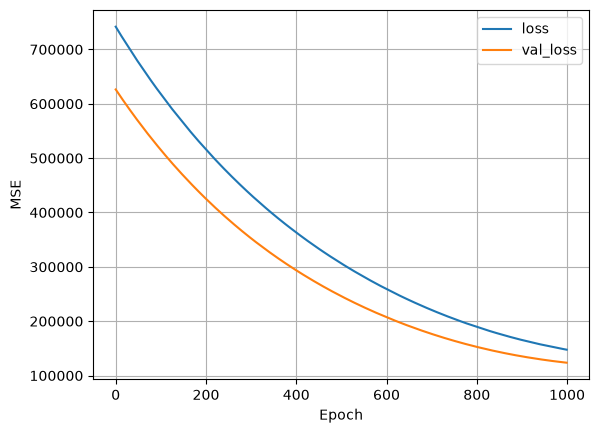

In [119]:
plot_loss(history)

### Visualizing the fitted neural network

Same idea as the earlier `LinearRegression` plot — scatter the real training data, then overlay the model's predicted curve across a smooth range of temperatures — but now `temp_nn_model` is the trained neural net (`temp_normalizer` → single `Dense(1)` layer) instead of the sklearn linear model.

**Why the reshape:** `tf.linspace(-20, 40, 100)` produces a flat, 1-D array of 100 temperature values, shaped `(100,)`. But `temp_nn_model.predict()` (like the sklearn model before it, and `get_xy` earlier in the notebook) expects its input as a 2-D array shaped `(num_samples, num_features)` — here, 100 samples of 1 feature each, i.e. `(100, 1)`. `np.array(x).reshape(-1, 1)` converts `x` from a flat `(100,)` array into that expected `(100, 1)` column shape (`-1` tells NumPy to infer 100 automatically from the array's length), so `.predict()` doesn't reject it or misread it as one sample with 100 features.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


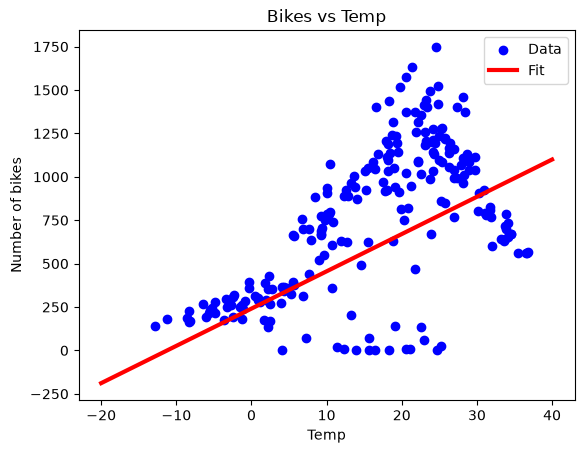

In [120]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

### Approach 2: a real (non-linear) neural network

This block builds `nn_model` with **three hidden layers of 32 neurons each, using `relu` activations**, before the final `Dense(1)` output — unlike Approach 1's bare `Dense(1)`, this network has genuine depth and non-linearity, so it can learn curved, non-linear relationships between temperature and bike demand instead of being limited to a straight line.

**Key differences from Approach 1:**

| | Approach 1 (`temp_nn_model`) | Approach 2 (`nn_model`) |
|---|---|---|
| Architecture | `Normalization` → `Dense(1)` | `Normalization` → `Dense(32, relu)` × 3 → `Dense(1)` |
| Can fit non-linear curves? | No — mathematically a straight line | Yes — the `relu` activations let it bend |
| Learning rate | `0.1` | `0.001` (10-100x smaller) |
| Epochs | `1000` | `100` |
| Equivalent to | Linear regression | An actual multi-layer neural network |

The learning rate is much smaller here because deeper networks with more parameters are more prone to unstable/diverging updates at high learning rates — the earlier single-layer model could tolerate an aggressive `0.1` since it only has one weight and one bias to update, but this deeper network needs smaller, more careful steps to train stably.

*Process* — builds and compiles `nn_model`. No output expected here; this just defines the architecture and sets the optimizer/loss, it doesn't train anything yet.

In [121]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

*Process* — runs training (`verbose=0`, so nothing prints). Each epoch does a full forward/backward pass over `X_train_temp`/`y_train_temp` and records train and validation loss into `history`, which the next cells visualize.

In [122]:
history = nn_model.fit(
    X_train_temp, y_train_temp,
    validation_data=(X_val_temp, y_val_temp),
    verbose=0, epochs=100
)

*Observation* — train and validation MSE both start high (~625k–745k), stay roughly flat through the first ~25 epochs, then drop sharply and converge to ~120k–130k by epoch 60–100, with the two curves tracking each other closely throughout (validation loss is never meaningfully worse than training loss).

**Conclusion:** training converged successfully, and there's no sign of overfitting — if the network were memorizing the training set rather than generalizing, we'd expect validation loss to plateau or rise while training loss kept falling. Since both curves fall together, this deeper 3-hidden-layer network is fitting real structure in the temp→bike_count relationship, not just noise.

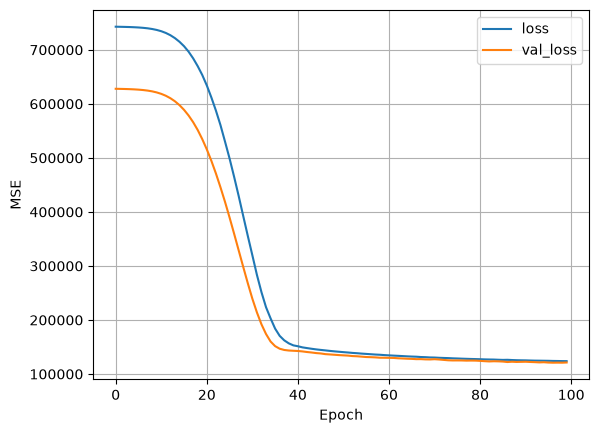

In [123]:
plot_loss(history)

*Observation* — unlike Approach 1's straight red line, this fitted curve is genuinely non-linear: it dips slightly from about 425 bikes at −20°C down to roughly 375 near −5°C, stays fairly flat through the low single digits, then rises steadily up to about 1,300 bikes by 40°C. The underlying data is still very scattered (bike counts from 0 to ~1,750 across most of the temperature range), so the curve doesn't hug the data tightly.

**Conclusion:** the network learned a curved relationship instead of being forced into a straight line — concretely, it picked up that very cold temperatures don't suppress ridership quite as much as a linear fit would suggest (there's a slight dip-then-rise rather than a monotonic increase from the coldest point), which is closer to real cycling behavior. That said, temperature alone still leaves a lot of scatter unexplained (same limitation the temperature-only linear model had) — the non-linearity improves the *shape* of the fit, but a single feature is still not enough to tightly predict bike demand.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


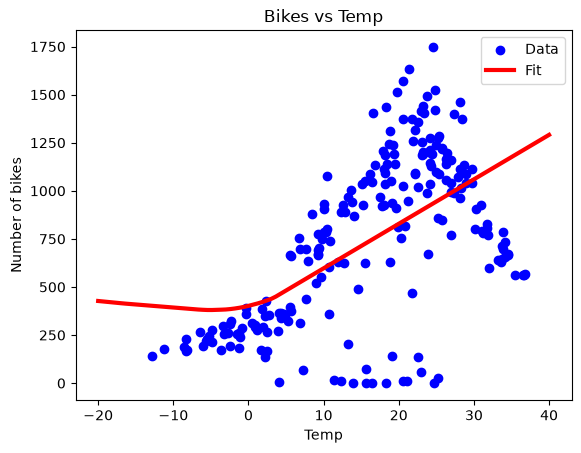

In [124]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

### Neural network on all features

Same idea as Approach 2 above, but now trained on the full 6-feature set (`X_train_all`) instead of temperature alone — this is the neural-network counterpart to `all_reg`, the multiple linear regression model fit earlier.

*Process* — builds the `Normalization` layer for all 6 input features. Note `axis=-1` here (vs. `axis=None` for the single-feature `temp_normalizer`): with multiple features on different scales (e.g. temperature in °C vs. humidity in %), each column needs its *own* mean/variance computed independently so no feature dominates purely due to scale; `axis=None` was fine for a single feature since there was only one scale to begin with.

In [125]:
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,), axis=-1)
all_normalizer.adapt(X_train_all)

*Process* — builds and compiles this `nn_model`: `Normalization` → two hidden `Dense(32, relu)` layers → `Dense(1)` output. One fewer hidden layer than the temperature-only Approach 2 network (2 vs. 3), since with 6 real features there's already more signal to work with than a single scalar input.

In [126]:
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

*Process* — trains `nn_model` on all 6 features for 100 epochs (`verbose=0`, so nothing prints). Records train/validation loss into `history` for the plot below.

In [127]:
history = nn_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val_all, y_val_all),
    verbose=0, epochs=100
)

*Observation* — training MSE starts around 630k and drops smoothly to ~120k by epoch 100. Validation loss starts noticeably higher (~775k) and also falls, but stays above the training curve for the entire run, ending around ~150k while training loss is ~120k — a persistent, if modest, gap between the two.

**Conclusion:** this is a mild overfitting signal — with 6 features and a small dataset (only the noon rows survived the earlier filter, roughly ~230 samples split three ways), a 2-hidden-layer, 32-neuron-wide network has enough capacity to fit training-set quirks that don't generalize quite as well to the validation set. It's not runaway overfitting (both curves still trend down together), but it foreshadows the next cells' result: this larger network may not actually beat the much simpler linear regression model on unseen data.

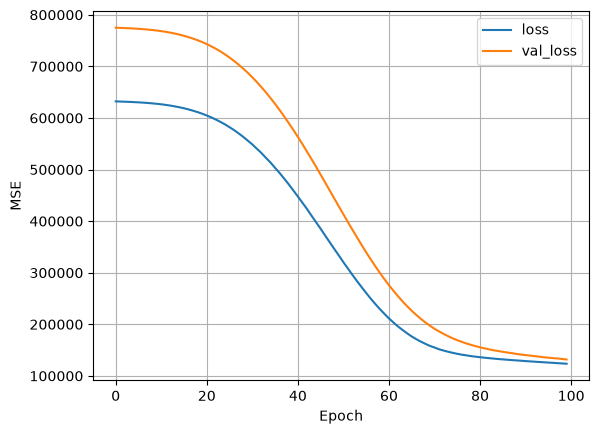

In [128]:
plot_loss(history)

*Process* — generates predictions from both models (`all_reg` and `nn_model`) on the held-out test set, so they can be compared head-to-head below.

In [129]:
# calculate the MSE for both linear reg and nn
y_pred_lr = all_reg.predict(X_test_all)
y_pred_nn = nn_model.predict(X_test_all)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


*Process* — defines a manual MSE helper (mirrors the RMSE/MSE formula from the "Evaluation of Linear Regression Models" section earlier) for comparing the two models' predictions.

In [130]:
def MSE(y_pred, y_real):
  return (np.square(y_pred - y_real)).mean()

*Observation* — linear regression's test-set MSE is **104,323**.

In [131]:
MSE(y_pred_lr, y_test_all)

np.float64(104322.93643051457)

*Observation* — the neural network's test-set MSE is **132,386**, noticeably higher (worse) than linear regression's 104,323.

**Conclusion:** despite having far more capacity (two hidden layers of 32 neurons vs. a single linear equation), `nn_model` performs *worse* than `all_reg` on unseen data — consistent with the mild overfitting seen in the loss plot above. With only ~230 samples and 6 features, the dataset is too small for the deeper network's extra flexibility to pay off; the simpler linear model generalizes better here. This is a useful, somewhat counterintuitive result: more model capacity isn't automatically better — it needs enough data to justify it, or techniques like dropout/regularization/more epochs of careful tuning to avoid overfitting.

In [132]:
MSE(y_pred_nn, y_test_all)

np.float64(132386.49847474456)

*Observation* — the red diagonal line is "perfect prediction" (true value = predicted value); the closer a dot sits to it, the more accurate that prediction. Both models' predictions scatter fairly widely around the line rather than hugging it — neither is close to perfect — but the orange NN dots show a slightly wider, more erratic spread than the blue linear-regression dots, especially at the higher true-value end (e.g. several NN predictions clustered around 600–700 for true values above 1,250, well below the diagonal).

**Conclusion:** this visual matches the MSE numbers above — linear regression's predictions track the diagonal a bit more consistently than the neural network's. Neither model is strongly predictive on its own (both leave substantial scatter), reinforcing that with only 6 features and a small sample, a simple linear model is the more reliable choice here over a higher-capacity neural network.

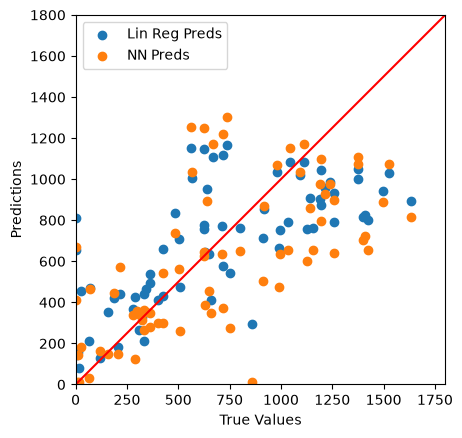

In [133]:
ax = plt.axes(aspect="equal")
plt.scatter(y_test_all, y_pred_lr, label="Lin Reg Preds")
plt.scatter(y_test_all, y_pred_nn, label="NN Preds")
plt.xlabel("True Values")
plt.ylabel("Predictions")
lims = [0, 1800]
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
_ = plt.plot(lims, lims, c="red")